<div style="text-align:center;">
    <h3>Introduction to Machine Learning</h3>
</div>
<div style="text-align:center;">
    <h4> Assignment 3/ Project </h4>
</div>
<div style="text-align:center;">
    <span style="font-size: 20px; background-color:pink; color:black;">
        Image Caption Generation
    </span>
</div>

Team Members:
- Jahnavi Agrawal (1020231300)
- Neha Palak (1020231795)




## <span style="background-color:yellow; color:black">TASK 1: Introduction</span>

***

The ArtEmis dataset is a large-scale collection of artwork images from WikiArt, each paired with human-written captions that describe not only the visual content but also the emotional and interpretive aspects of art. It connects visual understanding with human affective responses, making it ideal for studying image caption generation that goes beyond object recognition.

The goal of this project is to <u>generate meaningful captions for artworks</u> using two different deep learning approaches:

* **CNN + LSTM model**: trained from scratch to extract image features and generate captions word-by-word.
* **Vision–Language Transformer**: model that jointly learns image and text representations for caption generation.

This task also involves a <u>comparison of text embeddings and sequence modeling methods</u>, such as TF-IDF, Word2Vec, GloVe, and FastText, to understand how different embedding strategies affect caption fluency and quality.


***

## <span style="background-color:yellow; color:black">TASK 2: Exploratory Data Analysis (EDA)</span>

***



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("artemis_dataset.csv")
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 454684 entries, 0 to 454683
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   art_style   454684 non-null  object
 1   painting    454684 non-null  object
 2   emotion     454684 non-null  object
 3   utterance   454684 non-null  object
 4   repetition  454684 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 17.3+ MB


In [4]:
# Basic stats
print("num rows:", len(df))
print("unique paintings:", df['painting'].nunique())
print("captions per painting (describe):")
print(df.groupby('painting').size().describe())

# Emotions and art styles
print(df['emotion'].value_counts())
print(df['art_style'].value_counts()[:20])

# repetition column quick look
print("unique repetition values:", df['repetition'].unique())
print(df[['painting','utterance','repetition']].head(20))

num rows: 454684
unique paintings: 80031
captions per painting (describe):
count    80031.000000
mean         5.681348
std          4.025648
min          5.000000
25%          5.000000
50%          5.000000
75%          5.000000
max         58.000000
dtype: float64
emotion
contentment       126134
awe                72927
something else     52962
sadness            49061
amusement          45336
fear               41577
excitement         37636
disgust            22411
anger               6640
Name: count, dtype: int64
art_style
Impressionism                 72361
Realism                       59681
Romanticism                   39069
Expressionism                 38717
Post_Impressionism            36374
Art_Nouveau_Modern            24711
Symbolism                     24103
Baroque                       23469
Abstract_Expressionism        16075
Northern_Renaissance          14160
Naive_Art_Primitivism         14086
Rococo                        11904
Cubism                        114

In [9]:
caption_counts = df.groupby('painting').size()
caption_counts.describe()


count    80031.000000
mean         5.681348
std          4.025648
min          5.000000
25%          5.000000
50%          5.000000
75%          5.000000
max         58.000000
dtype: float64

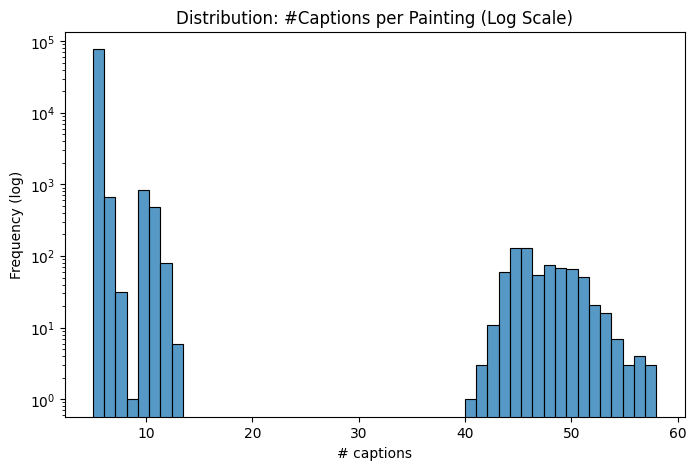

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(caption_counts, bins=50)
plt.yscale("log")
plt.title("Distribution: #Captions per Painting (Log Scale)")
plt.xlabel("# captions")
plt.ylabel("Frequency (log)")
plt.show()


Most paintings have 5–7 affective explanations, with a mean of ~5.68. A small subset (<1%) has 40+ captions because these artworks were shown to more annotators (‘rest’ category). The distribution is highly skewed, so we visualize the main region (0–15 captions) separately and use log scaling to examine the tail.


* Caption Length

In [ ]:
df['token_count'] = df['utterance'].str.split().apply(len)
df['token_count'].describe()


count    454684.000000
mean         15.685533
std           7.946779
min           1.000000
25%          11.000000
50%          14.000000
75%          18.000000
max         202.000000
Name: token_count, dtype: float64

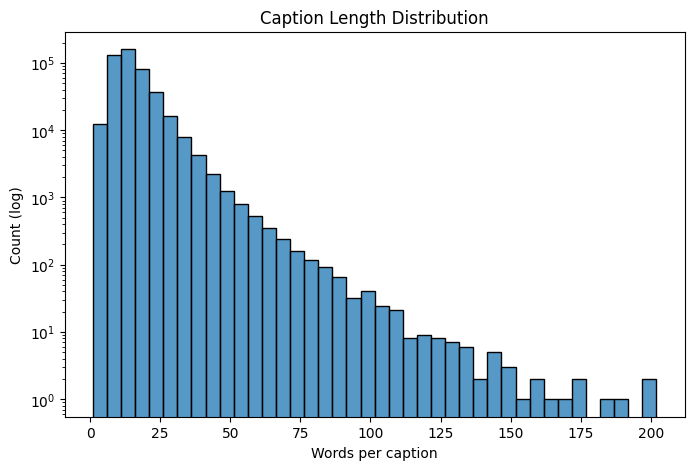

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['token_count'], bins=40)
plt.yscale("log")
plt.title("Caption Length Distribution")
plt.xlabel("Words per caption")
plt.ylabel("Count (log)")
plt.show()




In [13]:
df['token_count'].quantile([0.5, 0.75, 0.90, 0.95, 0.99])


0.50    14.0
0.75    18.0
0.90    25.0
0.95    30.0
0.99    45.0
Name: token_count, dtype: float64

The caption length distribution shows that most explanations in the ArtEmis dataset are relatively short and compact, with half of them containing 14 words or fewer and 75% staying under 18 words. However, there is a noticeable long-tail pattern where some annotators provide much longer, more detailed emotional responses, with the longest 1% reaching up to around 45 words. Because of this imbalance, the model needs a fixed padded sequence length that is long enough to avoid cutting off meaningful content from longer captions while still keeping computation efficient. A sequence length of about 25 tokens strikes this balance well, capturing over 90% of captions without excessive padding.


* Emotion Distribution

In [14]:
emotion_counts = df['emotion'].value_counts()
emotion_counts


emotion
contentment       126134
awe                72927
something else     52962
sadness            49061
amusement          45336
fear               41577
excitement         37636
disgust            22411
anger               6640
Name: count, dtype: int64

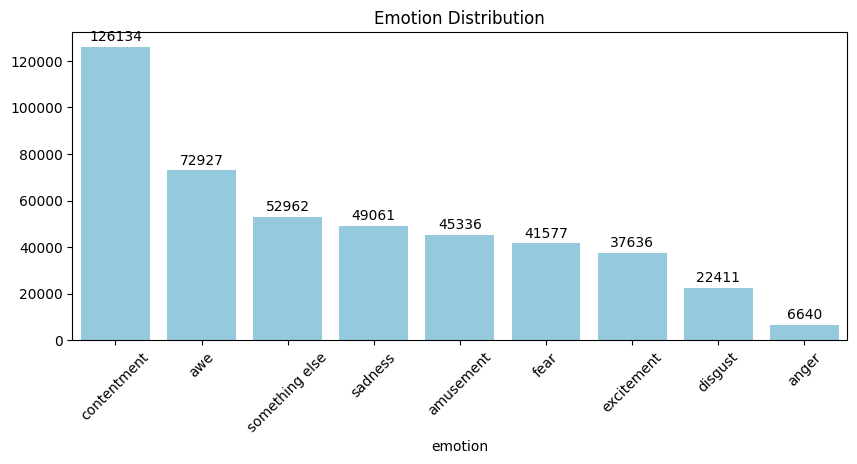

In [16]:
plt.figure(figsize=(10,4))
ax = sns.barplot(x=emotion_counts.index, 
                 y=emotion_counts.values, 
                 color='skyblue')

plt.title("Emotion Distribution")
plt.xticks(rotation=45)

# Add values on top of each bar
for i, v in enumerate(emotion_counts.values):
    ax.text(i, v + (0.01 * max(emotion_counts.values)),   # small offset above bar
            str(v), 
            ha='center', va='bottom', fontsize=10)

plt.show()


The emotion distribution in the ArtEmis dataset is highly imbalanced. Contentment is by far the most common emotion, with over 126k annotations, followed by awe (~73k) and “something else” (~53k). Mid-frequency emotions include sadness, amusement, fear, and excitement, each ranging between 37k–49k examples. In contrast, negative emotions such as disgust (~22k) and especially anger (~6.6k) are relatively rare. This skew suggests that the dataset primarily reflects positive or neutral affect, which may bias models to generate less emotionally intense captions unless balanced or weighted appropriately.

* Art Style Distribution

In [20]:
style_counts = df['art_style'].value_counts()
style_counts


art_style
Impressionism                 72361
Realism                       59681
Romanticism                   39069
Expressionism                 38717
Post_Impressionism            36374
Art_Nouveau_Modern            24711
Symbolism                     24103
Baroque                       23469
Abstract_Expressionism        16075
Northern_Renaissance          14160
Naive_Art_Primitivism         14086
Rococo                        11904
Cubism                        11462
Color_Field_Painting           9836
Pop_Art                        8438
Early_Renaissance              7622
High_Renaissance               7366
Minimalism                     7163
Mannerism_Late_Renaissance     7047
Ukiyo_e                        6615
Fauvism                        4191
Contemporary_Realism           2953
Pointillism                    2870
New_Realism                    1848
Synthetic_Cubism               1284
Action_painting                 664
Analytical_Cubism               615
Name: count, dtype

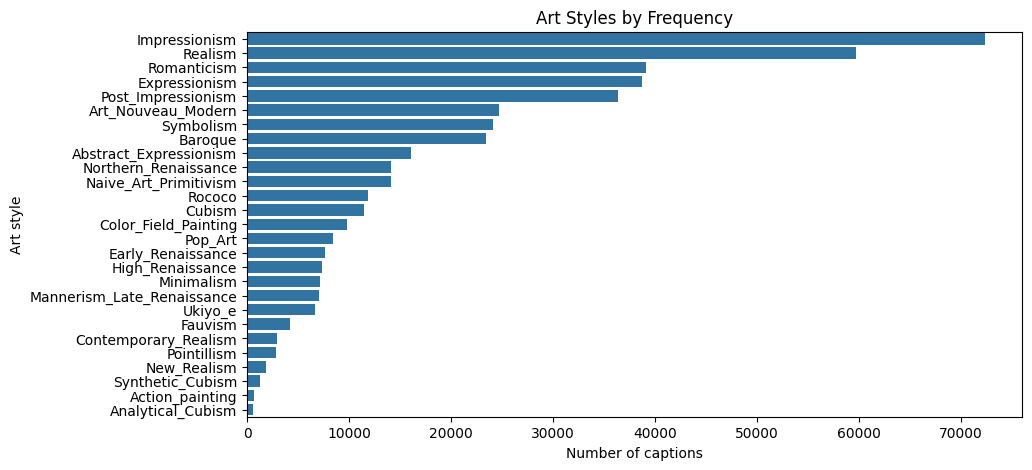

In [21]:
plt.figure(figsize=(10,5))
sns.barplot(y=style_counts.index, x=style_counts.values)
plt.title("Art Styles by Frequency")
plt.xlabel("Number of captions")
plt.ylabel("Art style")
plt.show()


The art style distribution is highly imbalanced, with a few styles dominating the dataset. Impressionism, Realism, and Romanticism have the largest number of captions, while many other styles appear far less frequently. This long-tailed pattern shows that the dataset is rich but uneven, with certain art movements far more represented than others.


* Repetition Columns

In [24]:
df['repetition'].value_counts().sort_index()
df[['painting','utterance','repetition']].head(20)


,painting,utterance,repetition
0,vincent-van-gogh_portrait-of-madame-ginoux-l-a...,"She seems very happy in the picture, and you w...",10
1,vincent-van-gogh_portrait-of-madame-ginoux-l-a...,This woman has really knotty hands which makes...,10
2,vincent-van-gogh_portrait-of-madame-ginoux-l-a...,"When looking at this woman, I am filled with c...",10
3,vincent-van-gogh_portrait-of-madame-ginoux-l-a...,"A woman looking at ease, peaceful, and satisfi...",10
4,vincent-van-gogh_portrait-of-madame-ginoux-l-a...,She looks like a lady from that past that migh...,10
5,wassily-kandinsky_study-for-autumn-1909,The bright colors make a very unique scene for...,7
6,wassily-kandinsky_study-for-autumn-1909,"The way the image is presented, with large chu...",7
7,konstantin-korovin_yaroslavna-s-lament-1909,the stroke of blue paint used to outline the h...,7
8,konstantin-korovin_yaroslavna-s-lament-1909,Some of the wooden panels are falling from the...,7
9,paul-gauguin_mette-gauguin-in-an-evening-dress...,The golden gloves and white dress stand out an...,7


In [25]:
df_unique = df.drop_duplicates(subset=['painting','utterance'])


In [26]:
df.sample(10)


,art_style,painting,emotion,utterance,repetition,token_count
57559,Cubism,kazimir-malevich_the-reaper-on-red-1913,something else,This painting makes me feel cautious. The subj...,5,41
436243,Post_Impressionism,henri-de-toulouse-lautrec_henri-gabriel-ibels-...,amusement,The position and facial expression make this m...,45,15
282882,Mannerism_Late_Renaissance,tintoretto_ascension-of-christ-1581,awe,There is so much detail and things going on in...,5,23
423317,Romanticism,karl-bodmer_funeral-scaffold-of-a-sioux-chief-...,awe,It's a beautiful photo-realistic look at a tim...,5,14
310988,Realism,thomas-eakins_study-of-a-horse-s-leg-for-the-f...,contentment,The piece here is quite bland and obscure. How...,6,20
376649,Impressionism,pericles-pantazis_still-life-with-quinces-1880,contentment,I feel peaceful looking this still life. The ...,7,18
173064,Symbolism,felicien-rops_the-sphinx-1882,disgust,This painting is full of satanic and/or pagan ...,5,9
281515,Color_Field_Painting,leon-berkowitz_cup-7-1975,something else,it is just a gradual change in colors that mak...,5,15
246197,Cubism,m.c.-escher_not_detected_204650,disgust,The black and white sketch in the painting of ...,6,22
117105,Abstract_Expressionism,georgia-o'keeffe_green-yellow-and-orange,awe,The bright colors and the unknown shapes that ...,5,10


In [33]:
from collections import Counter
import re

def clean(text):
    return re.sub(r"[^a-zA-Z ]","",text.lower()).split()

words = Counter()
df['utterance'].sample(20000).apply(lambda s: words.update(clean(s)))

words.most_common(20)


[('the', 28782),
 ('and', 11235),
 ('a', 10493),
 ('of', 9234),
 ('is', 8002),
 ('to', 5834),
 ('in', 5565),
 ('like', 5300),
 ('this', 5173),
 ('it', 4233),
 ('i', 4210),
 ('looks', 4097),
 ('me', 3321),
 ('are', 3129),
 ('on', 2828),
 ('with', 2572),
 ('painting', 2142),
 ('look', 2068),
 ('colors', 2060),
 ('makes', 2053)]

***

## <span style="background-color:yellow; color:black">TASK 3: Preprocessing</span>

***



In [4]:
import pandas as pd

df = pd.read_csv("data_preprocessed/artemis_subsampled.csv")
print("Unique paintings:", df['painting'].nunique())
print("Total rows:", len(df))


Unique paintings: 7500
Total rows: 43082


In [5]:
import pandas as pd
df = pd.read_csv("data_preprocessed/artemis_subsampled.csv")
print(df['painting'].nunique())


7500


***

## <span style="background-color:yellow; color:black">TASK 4: Text Representation</span>

***



***

## <span style="background-color:yellow; color:black">TASK 5: Models</span>

***



***

### <span style="background-color:#33cccc; color:black">Model 1 : CNN + LSTM Network</span>

***



***

### <span style="background-color:#33cccc; color:black">Model 2 : Vision-Language Transformer</span>

***



***

## <span style="background-color:yellow; color:black">TASK 6: Training and Evaluation</span>

***



***

## <span style="background-color:yellow; color:black">TASK 7: Analysis and Discussion</span>

***



***

## <span style="background-color:yellow; color:black">TASK 8: Conclusion </span>

***
write here only

***

## <span style="background-color:yellow; color:black">TASK 9: Reference</span>

***
1. CNN models for Image Captioning: https://www.researchgate.net/publication/355978058_Comparison_of_Different_CNN_Model_used_as_Encoders_for_Image_Captioning
2. Embeddings and vectors: https://medium.com/@saschametzger/what-are-tokens-vectors-and-embeddings-how-do-you-create-them-e2a3e698e037 
3. How to subtokenize: https://www.geeksforgeeks.org/nlp/subword-tokenization-in-nlp/
